In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LATITUDE_FORMATTER, LONGITUDE_FORMATTER
import cftime
import datetime
from datetime import date
from matplotlib import pyplot
from matplotlib.cm import ScalarMappable
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import numpy
import pandas
from scipy.stats import gaussian_kde
import xarray as xr

In [2]:
# Define directories
Diri = '../ExtraTrack_Data/Output_Files_V7/'
Output_Diri = '../RCP_Figs/Analysis_Figs_V7.3.2/'

In [3]:
# Open file
def Open_File(File):
    DF = pandas.read_csv(File)
    DF = DF.drop("Unnamed: 0", axis=1)
    return (DF)

In [4]:
# Open each file
def Files_Open(Scenario, Diri, Subset):
    Data_DF = Open_File(Diri+Scenario+'_Data_'+Subset+'_Output.csv')
    ET_DF = Open_File(Diri+Scenario+'_ET_'+Subset+'_Output.csv')
    Codes_DF = Open_File(Diri+Scenario+'_Codes_Output.csv')
# Edit time format
    Time_Cols = ["ET Begin Time", "ET Complete Time", "Trop Peak Time", "Peak Time", "Genesis Time", "Final Time"]
    for Col in Time_Cols:
        ET_DF[Col] = pandas.to_datetime(ET_DF[Col], errors="coerce")
    Data_DF["Time(Z)"] = pandas.to_datetime(Data_DF["Time(Z)"], errors="coerce")
    return (Data_DF, ET_DF, Codes_DF)

In [5]:
# Create bins
def Create_Bins(Min, Max, Bin_Width):
    Bins = numpy.arange(Min, Max+Bin_Width, Bin_Width)
    return (Bins)
Lon_Bins = Create_Bins(-100,20,5)
Lat_Bins = Create_Bins(0,60,5)

In [6]:
# Number of years for each climate scenario
Num_Years = numpy.array([90,93,93])

In [7]:
# Open files
Control_Data, Control_ET, Control_Codes = Files_Open("Control", Diri, "SubsetB")
RCP45_Data, RCP45_ET, RCP45_Codes = Files_Open("RCP45", Diri, "SubsetB")
RCP85_Data, RCP85_ET, RCP85_Codes = Files_Open("RCP85", Diri, "SubsetB")

In [8]:
# Function for computing smooth probability distribution and approximating smooth cumulative distribution
def KDE_PDF_CDF(Data, Min, Max, Bin_Width, Smooth_Param):
# Compute PDF
    Values = Create_Bins(Min, Max, Bin_Width)
    KDE = gaussian_kde(Data, bw_method=Smooth_Param)
    PDF = KDE(Values)
# Numerical integration to obtain cumulative distribution
    dx = numpy.diff(Values)
    CDF = numpy.zeros(len(Values))
    CDF[1:] = numpy.cumsum(0.5 * (PDF[:-1] + PDF[1:]) * dx)
    CDF = CDF / CDF[-1]
    return (Values, PDF, CDF)

In [9]:
# Function for applying SLP bounds
def ET_SLP_Bounds(Control_ET, RCP45_ET, RCP85_ET, Var, Low_Bound, Up_Bound):
    Control_ET_Bound = Control_ET[(Control_ET[Var] <= Up_Bound) & (Control_ET[Var] >= Low_Bound)].reset_index(drop=True)
    RCP45_ET_Bound = RCP45_ET[(RCP45_ET[Var] <= Up_Bound) & (RCP45_ET[Var] >= Low_Bound)].reset_index(drop=True)
    RCP85_ET_Bound = RCP85_ET[(RCP85_ET[Var] <= Up_Bound) & (RCP85_ET[Var] >= Low_Bound)].reset_index(drop=True)
    return (Control_ET_Bound, RCP45_ET_Bound, RCP85_ET_Bound)

In [10]:
# Function for plotting cumulative distribution frequency
def Plot_CDF(Axis, Control_Array, RCP45_Array, RCP85_Array, Min, Max, Bin_Width, Smooth_Param):
    Control_Values, Control_PDF, Control_CDF = KDE_PDF_CDF(numpy.array(Control_Array), Min, Max, Bin_Width, Smooth_Param)
    RCP45_Values, RCP45_PDF, RCP45_CDF = KDE_PDF_CDF(numpy.array(RCP45_Array), Min, Max, Bin_Width, Smooth_Param)
    RCP85_Values, RCP85_PDF, RCP85_CDF = KDE_PDF_CDF(numpy.array(RCP85_Array), Min, Max, Bin_Width, Smooth_Param)
    if Horiz == False:
        Axis.plot(Control_Values, Control_CDF, color='limegreen', linewidth=2.8, label='Control', alpha=0.8)
        Axis.plot(RCP45_Values, RCP45_CDF, color='orange', linewidth=2.8, label='RCP4.5', alpha=0.8)
        Axis.plot(RCP85_Values, RCP85_CDF, color='red', linewidth=2.8, label='RCP8.5', alpha=0.8)
    else:
        Axis.plot(Control_CDF, Control_Values, color='limegreen', linewidth=2.8, label='Control', alpha=0.8)
        Axis.plot(RCP45_CDF, RCP45_Values, color='orange', linewidth=2.8, label='RCP4.5', alpha=0.8)
        Axis.plot(RCP85_CDF, RCP85_Values, color='red', linewidth=2.8, label='RCP8.5', alpha=0.8)

In [11]:
# Function for plotting probability distribution frequency
def Plot_PDF(Axis, Control_Array, RCP45_Array, RCP85_Array, Min, Max, Bin_Width, Smooth_Param):
    Control_Values, Control_PDF, Control_CDF = KDE_PDF_CDF(numpy.array(Control_Array), Min, Max, Bin_Width, Smooth_Param)
    RCP45_Values, RCP45_PDF, RCP45_CDF = KDE_PDF_CDF(numpy.array(RCP45_Array), Min, Max, Bin_Width, Smooth_Param)
    RCP85_Values, RCP85_PDF, RCP85_CDF = KDE_PDF_CDF(numpy.array(RCP85_Array), Min, Max, Bin_Width, Smooth_Param)
    if Horiz == False:
        Axis.plot(Control_Values, Control_PDF, color='limegreen', linewidth=2.8, label='Control', alpha=0.8)
        Axis.plot(RCP45_Values, RCP45_PDF, color='orange', linewidth=2.8, label='RCP4.5', alpha=0.8)
        Axis.plot(RCP85_Values, RCP85_PDF, color='red', linewidth=2.8, label='RCP8.5', alpha=0.8)
    else:
        Axis.plot(Control_PDF, Control_Values, color='limegreen', linewidth=2.8, label='Control', alpha=0.8)
        Axis.plot(RCP45_PDF, RCP45_Values, color='orange', linewidth=2.8, label='RCP4.5', alpha=0.8)
        Axis.plot(RCP85_PDF, RCP85_Values, color='red', linewidth=2.8, label='RCP8.5', alpha=0.8)

In [12]:
# Create function to plot ET cumulative and probability distributions
def ET_Distr_Plot(Control_ET, RCP45_ET, RCP85_ET, Var, Var_Label, Horiz, \
    Mins, Maxes, Bin_Widths, Label_Widths, Smooth_Param, Plot, Savefig, Figname):
    Fig = pyplot.figure(figsize=(16,16))
#
# Plot genesis
    if Var != "SLP":
        Axis = Fig.add_subplot(2,2,1)
        Var0 = "Genesis " + Var
        Control_ET_Genesis, RCP45_ET_Genesis, RCP85_ET_Genesis = \
        ET_SLP_Bounds(Control_ET, RCP45_ET, RCP85_ET, "Genesis SLP", 728, 1013)
# Apply plot CDF function
        if Plot == "CDF":
            Plot_CDF(Axis, Control_ET_Genesis[Var0], RCP45_ET_Genesis[Var0], RCP85_ET_Genesis[Var0], Mins[0], Maxes[0], Bin_Widths[0], Smooth_Param)
            CDF_Formatting(Axis, 0, Var, Horiz, Mins[0], Maxes[0], Label_Widths[0], str("Genesis " + Var_Label))
# Apply plot PDF function
        elif Plot == "PDF":
            Plot_PDF(Axis, Control_ET_Genesis[Var0], RCP45_ET_Genesis[Var0], RCP85_ET_Genesis[Var0], Mins[0], Maxes[0], Bin_Widths[0], Smooth_Param)
            PDF_Formatting(Axis, 0, Var, Horiz, Mins[0], Maxes[0], Label_Widths[0], str("Genesis " + Var_Label))
#
# Plot storm peak
    else:
        Axis = Fig.add_subplot(2,2,1)
        Var0 = "Peak " + Var
        Control_ET_Peak, RCP45_ET_Peak, RCP85_ET_Peak = \
        ET_SLP_Bounds(Control_ET, RCP45_ET, RCP85_ET, "Peak SLP", 728, 1013)
# Apply plot CDF function
        if Plot == "CDF":
            Plot_CDF(Axis, Control_ET_Peak[Var0], RCP45_ET_Peak[Var0], RCP85_ET_Peak[Var0], Mins[0], Maxes[0], Bin_Widths[0], Smooth_Param)
            CDF_Formatting(Axis, 0, Var, Horiz, Mins[0], Maxes[0], Label_Widths[0], str("Peak " + Var_Label))
# Apply plot PDF function
        elif Plot == "PDF":
            Plot_PDF(Axis, Control_ET_Peak[Var0], RCP45_ET_Peak[Var0], RCP85_ET_Peak[Var0], Mins[0], Maxes[0], Bin_Widths[0], Smooth_Param)
            PDF_Formatting(Axis, 0, Var, Horiz, Mins[0], Maxes[0], Label_Widths[0], str("Peak " + Var_Label))

# Legend
    pyplot.legend(loc=4, fontsize=15)
#
# Plot tropical peak
    Axis = Fig.add_subplot(2,2,2)
    Var1 = "Trop Peak " + Var
    Control_ET_Trop_Peak, RCP45_ET_Trop_Peak, RCP85_ET_Trop_Peak = \
    ET_SLP_Bounds(Control_ET, RCP45_ET, RCP85_ET, "Trop Peak SLP", 728, 1000)
# Apply plot CDF function
    if Plot == "CDF":
        Plot_CDF(Axis, Control_ET_Trop_Peak[Var1], RCP45_ET_Trop_Peak[Var1], RCP85_ET_Trop_Peak[Var1], Mins[1], Maxes[1], Bin_Widths[1], Smooth_Param)
        CDF_Formatting(Axis, 1, Var, Horiz, Mins[1], Maxes[1], Label_Widths[1], str("Tropical Peak " + Var_Label))
# Apply plot PDF function
    elif Plot == "PDF":
        Plot_PDF(Axis, Control_ET_Trop_Peak[Var1], RCP45_ET_Trop_Peak[Var1], RCP85_ET_Trop_Peak[Var1], Mins[1], Maxes[1], Bin_Widths[1], Smooth_Param)
        PDF_Formatting(Axis, 1, Var, Horiz, Mins[1], Maxes[1], Label_Widths[1], str("Tropical Peak " + Var_Label))
#
# Plot ET begin
    Axis = Fig.add_subplot(2,2,3)
    Var2 = "ET Begin " + Var
    Control_ET_Begin, RCP45_ET_Begin, RCP85_ET_Begin = \
    ET_SLP_Bounds(Control_ET, RCP45_ET, RCP85_ET, "ET Begin SLP", 728, 1010)
# Apply plot CDF function
    if Plot == "CDF":
        Plot_CDF(Axis, Control_ET_Begin[Var2], RCP45_ET_Begin[Var2], RCP85_ET_Begin[Var2], Mins[2], Maxes[2], Bin_Widths[2], Smooth_Param)
        CDF_Formatting(Axis, 2, Var, Horiz, Mins[2], Maxes[2], Label_Widths[2], str("ET Initiation " + Var_Label))
# Apply plot PDF function
    elif Plot == "PDF":
        Plot_PDF(Axis, Control_ET_Begin[Var2], RCP45_ET_Begin[Var2], RCP85_ET_Begin[Var2], Mins[2], Maxes[2], Bin_Widths[2], Smooth_Param)
        PDF_Formatting(Axis, 2, Var, Horiz, Mins[2], Maxes[2], Label_Widths[2], str("ET Initiation " + Var_Label))
#
# Plot ET complete
    Axis = Fig.add_subplot(2,2,4)
    Var3 = "ET Complete " + Var
    Control_ET_Compl, RCP45_ET_Compl, RCP85_ET_Compl = \
    ET_SLP_Bounds(Control_ET, RCP45_ET, RCP85_ET, "ET Complete SLP", 728, 1010)
# Apply plot CDF function
    if Plot == "CDF":
        Plot_CDF(Axis, Control_ET_Compl[Var3], RCP45_ET_Compl[Var3], RCP85_ET_Compl[Var3], Mins[3], Maxes[3], Bin_Widths[3], Smooth_Param)
        CDF_Formatting(Axis, 3, Var, Horiz, Mins[3], Maxes[3], Label_Widths[3], str("ET Completion " + Var_Label))
# Apply plot PDF function
    elif Plot == "PDF":
        Plot_PDF(Axis, Control_ET_Compl[Var3], RCP45_ET_Compl[Var3], RCP85_ET_Compl[Var3], Mins[3], Maxes[3], Bin_Widths[3], Smooth_Param)
        PDF_Formatting(Axis, 3, Var, Horiz, Mins[3], Maxes[3], Label_Widths[3], str("ET Completion " + Var_Label))
#
# Save fig
    Fig.tight_layout()
    if Savefig == True:
        Fig.savefig(Output_Diri+Figname, bbox_inches='tight')

In [13]:
# Formatting based on variable
def CDF_Formatting(Axis, Num, Var, Horiz, Min, Max, Width, Title):
# x ticks and limits
    x_Ticks = Create_Bins(Min, Max, Width)
# y ticks and limits
    if Horiz == False:
        pyplot.xticks(x_Ticks)
        pyplot.xlim(Min, Max)
        pyplot.yticks(Create_Bins(0,1,0.125))
        pyplot.ylim(0,1)
    else:
        pyplot.yticks(x_Ticks)
        pyplot.ylim(Min, Max)
        pyplot.xticks(Create_Bins(0,1,0.125))
        pyplot.xlim(0,1)
#
# Labels and title
    if Num == 2 or Num == 3:
        if Var == "Lat":
            pyplot.xlabel("Cumulative Frequency Density", fontsize=18)
        elif Var == "Lon":
            pyplot.xlabel("Longitude", fontsize=18)
        elif Var == "SLP" or Var == "SLP(hPa)":
            pyplot.xlabel("Sea Level Pressure (hPa)", fontsize=18)
    if Num == 0 or Num == 2:
        if Var == "Lat":
            pyplot.ylabel("Latitude", fontsize=18)
        else:
            pyplot.ylabel("Cumulative Frequency Density", fontsize=18)
    pyplot.title(Title, fontsize=25)
#
# Gridlines
    pyplot.grid(linewidth=0.3, color='silver', linestyle='-')
#
# Letter labels
    Letter_Label(Axis, Num)

In [14]:
# Formatting based on variable
def PDF_Formatting(Axis, Num, Var, Horiz, Min, Max, Width, Title):
# x ticks and limits
    x_Ticks = Create_Bins(Min, Max, Width)
# y ticks and limits
    if Horiz == False:
        pyplot.xticks(x_Ticks)
        pyplot.xlim(Min, Max)
        #pyplot.yticks(Create_Bins(0,1,0.125))
        #pyplot.ylim(0,1)
    else:
        pyplot.yticks(x_Ticks)
        pyplot.ylim(Min, Max)
        #pyplot.xticks(Create_Bins(0,1,0.125))
        #pyplot.xlim(0,1)
#
# Labels and title
    if Num == 2 or Num == 3:
        if Var == "Lat":
            pyplot.xlabel("Probability Frequency Density", fontsize=18)
        elif Var == "Lon":
            pyplot.xlabel("Longitude", fontsize=18)
        elif Var == "SLP" or Var == "SLP(hPa)":
            pyplot.xlabel("Sea Level Pressure (hPa)", fontsize=18)
    if Num == 0 or Num == 2:
        if Var == "Lat":
            pyplot.ylabel("Latitude", fontsize=18)
        else:
            pyplot.ylabel("Probability Frequency Density", fontsize=18)
    pyplot.title(Title, fontsize=25)
#
# Gridlines
    pyplot.grid(linewidth=0.3, color='silver', linestyle='-')
#
# Letter labels
    Letter_Label(Axis, Num)

In [15]:
# Create subsets for each storm phase
def Phase_Subsets(Data):
    Subset_0 = Data[Data["SLP(hPa)"] <= 1010].reset_index()
    Subset_Trop = Subset_0[Subset_0["Storm Phase"] == "Tropical"]
    Subset_Trans = Subset_0[(Subset_0["Storm Phase"] == "Transition")]
    Subset_Extra = Subset_0[Subset_0["Storm Phase"] == "Extratropical"]
    return (Subset_0, Subset_Trop, Subset_Trans, Subset_Extra)

In [16]:
# Create function to plot storm phase cumulative distributions
def Phase_Distr_Plot(Control_Data, RCP45_Data, RCP85_Data, Var, Var_Label, Horiz, \
    Mins, Maxes, Bin_Widths, Label_Widths, Smooth_Param, Plot, Savefig, Figname):
    Fig = pyplot.figure(figsize=(16,16))
#
# Create subsets
    Control_All, Control_Trop, Control_Trans, Control_Extra = Phase_Subsets(Control_Data)
    RCP45_All, RCP45_Trop, RCP45_Trans, RCP45_Extra = Phase_Subsets(RCP45_Data)
    RCP85_All, RCP85_Trop, RCP85_Trans, RCP85_Extra = Phase_Subsets(RCP85_Data)
#
# Plot all storms
    Axis = Fig.add_subplot(2,2,1)
# Apply plot CDF function
    if Plot == "CDF":
        Plot_CDF(Axis, Control_All[Var], RCP45_All[Var], RCP85_All[Var], Mins[0], Maxes[0], Bin_Widths[0], Smooth_Param)
        CDF_Formatting(Axis, 0, Var, Horiz, Mins[0], Maxes[0], Label_Widths[0], str(Var_Label + " (All)"))
# Apply plot PDF function
    elif Plot == "PDF":
        Plot_PDF(Axis, Control_All[Var], RCP45_All[Var], RCP85_All[Var], Mins[0], Maxes[0], Bin_Widths[0], Smooth_Param)
        PDF_Formatting(Axis, 0, Var, Horiz, Mins[0], Maxes[0], Label_Widths[0], str(Var_Label + " (All)"))
#
# Legend
    pyplot.legend(loc=4, fontsize=15)
#
# Plot tropical phase
    Axis = Fig.add_subplot(2,2,2)
# Apply plot CDF function
    if Plot == "CDF":
        Plot_CDF(Axis, Control_Trop[Var], RCP45_Trop[Var], RCP85_Trop[Var], Mins[1], Maxes[1], Bin_Widths[1], Smooth_Param)
        CDF_Formatting(Axis, 1, Var, Horiz, Mins[1], Maxes[1], Label_Widths[1], str(Var_Label + " (Tropical)"))
# Apply plot PDF function
    elif Plot == "PDF":
        Plot_PDF(Axis, Control_Trop[Var], RCP45_Trop[Var], RCP85_Trop[Var], Mins[1], Maxes[1], Bin_Widths[1], Smooth_Param)
        PDF_Formatting(Axis, 1, Var, Horiz, Mins[1], Maxes[1], Label_Widths[1], str(Var_Label + " (Tropical)"))
#
# Plot transitioning phase
    Axis = Fig.add_subplot(2,2,3)
# Apply plot CDF function
    if Plot == "CDF":
        Plot_CDF(Axis, Control_Trans[Var], RCP45_Trans[Var], RCP85_Trans[Var], Mins[2], Maxes[2], Bin_Widths[2], Smooth_Param)
        CDF_Formatting(Axis, 2, Var, Horiz, Mins[2], Maxes[2], Label_Widths[2], str(Var_Label + " (Transitioning)"))
# Apply plot PDF function
    elif Plot == "PDF":
        Plot_PDF(Axis, Control_Trans[Var], RCP45_Trans[Var], RCP85_Trans[Var], Mins[2], Maxes[2], Bin_Widths[2], Smooth_Param)
        PDF_Formatting(Axis, 2, Var, Horiz, Mins[2], Maxes[2], Label_Widths[2], str(Var_Label + " (Transitioning)"))
#
# Plot extratropical phase
    Axis = Fig.add_subplot(2,2,4)
# Apply plot CDF function
    if Plot == "CDF":
        Plot_CDF(Axis, Control_Extra[Var], RCP45_Extra[Var], RCP85_Extra[Var], Mins[3], Maxes[3], Bin_Widths[3], Smooth_Param)
        CDF_Formatting(Axis, 3, Var, Horiz, Mins[3], Maxes[3], Label_Widths[3], str(Var_Label + " (Extratropical)"))
# Apply plot PDF function
    elif Plot == "PDF":
        Plot_PDF(Axis, Control_Extra[Var], RCP45_Extra[Var], RCP85_Extra[Var], Mins[3], Maxes[3], Bin_Widths[3], Smooth_Param)
        PDF_Formatting(Axis, 3, Var, Horiz, Mins[3], Maxes[3], Label_Widths[3], str(Var_Label + " (Extratropical)"))
#
# Save fig
    Fig.tight_layout()
    if Savefig == True:
        Fig.savefig(Output_Diri+Figname, bbox_inches='tight')

In [17]:
# Letter labels
def Letter_Label(Axis, Plot):
    Fig_Labels = ['(a)','(b)','(c)','(d)', '(e)', '(f)', '(g)', '(h)', '(i)', '(j)', '(k)', '(l)']
    Axis.text(0.05, 0.95, str(Fig_Labels[int(Plot)]), ha='center', va='center', \
    transform=Axis.transAxes, fontdict={'size':24},color='black')

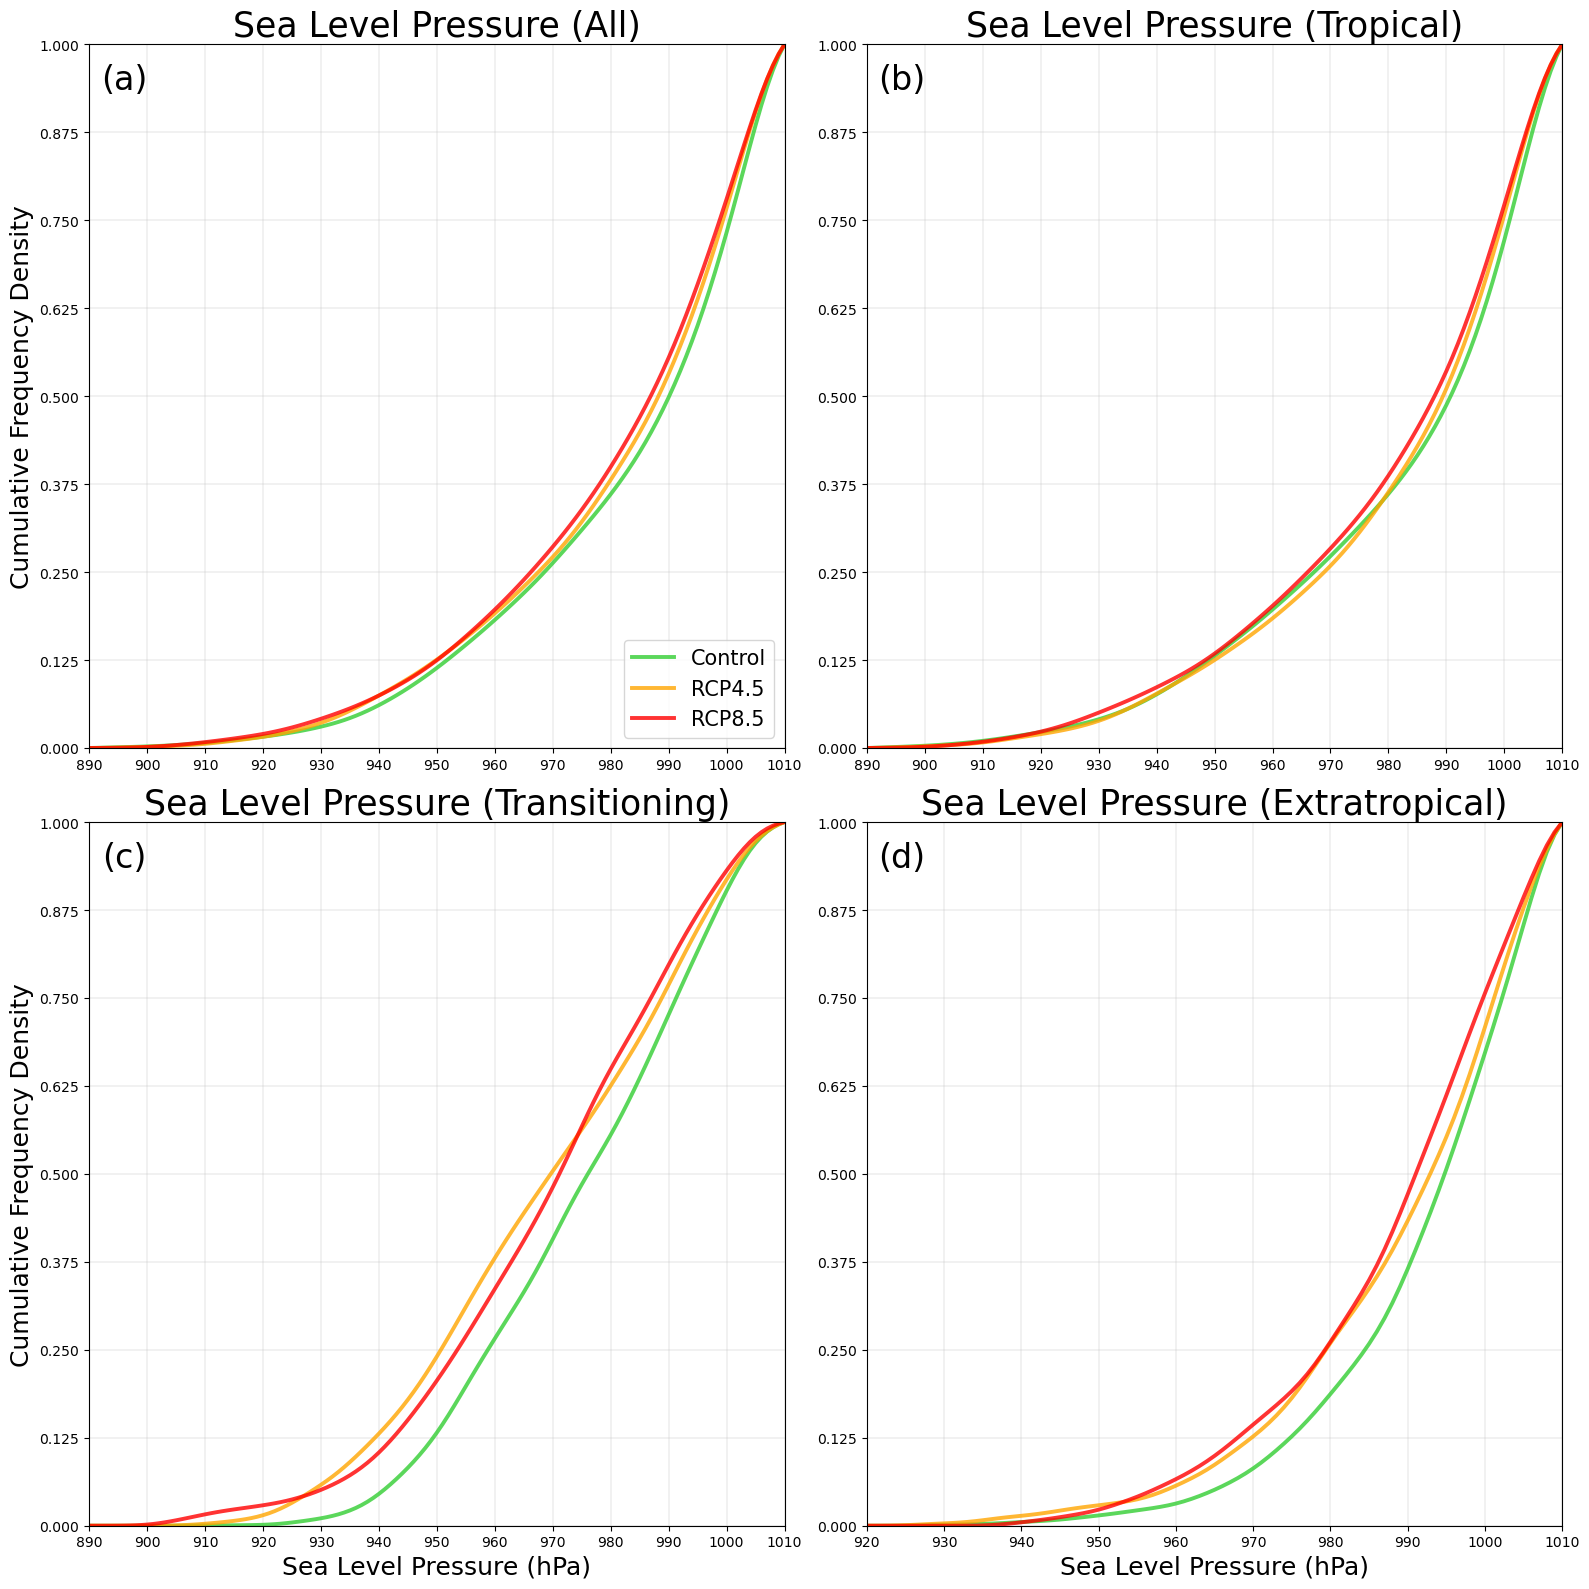

In [18]:
# Sea level pressure at each 6-hourly datapoints for each storm phase
Var = "SLP(hPa)"
Var_Label = "Sea Level Pressure"
Horiz = False
Mins = [890, 890, 890, 920]
Maxes = [1010, 1010, 1010, 1010]
Bin_Widths = [1, 1, 1, 1]
Label_Widths = [10, 10, 10, 10]
Smooth_Param = 0.15
Plot = "CDF"
Savefig = True
Figname = 'SLP_Phase_CDF.png'
Phase_Distr_Plot(Control_Data, RCP45_Data, RCP85_Data, Var, Var_Label, Horiz, \
Mins, Maxes, Bin_Widths, Label_Widths, Smooth_Param, Plot, Savefig, Figname)

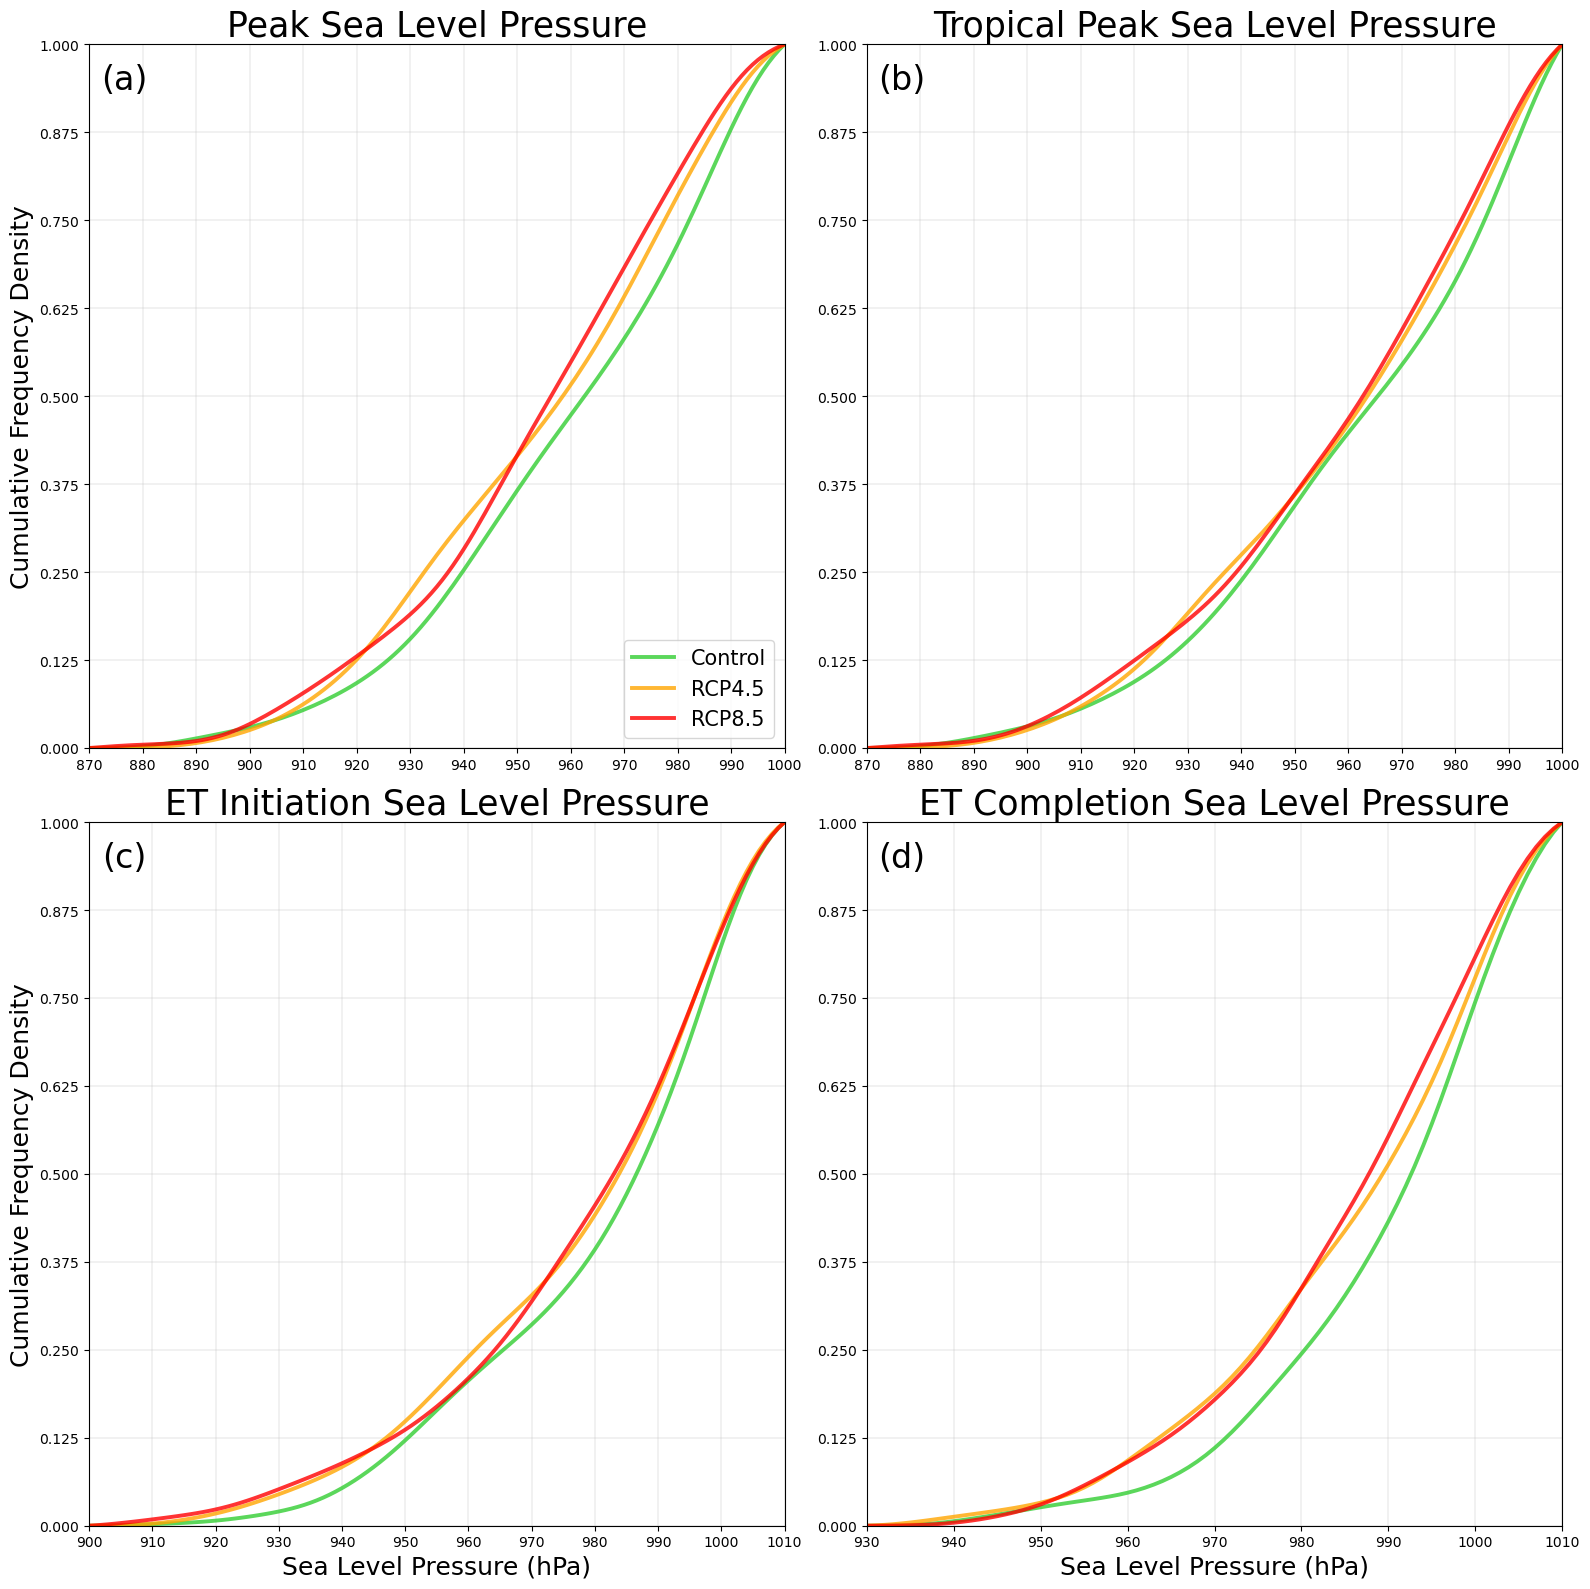

In [19]:
# Sea level pressure at peak, tropical peak, ET initiation and ET completion
Var = "SLP"
Var_Label = "Sea Level Pressure"
Horiz = False
Mins = [870, 870, 900, 930]
Maxes = [1000, 1000, 1010, 1010]
Bin_Widths = [1, 1, 1, 1]
Label_Widths = [10, 10, 10, 10]
Smooth_Param = 0.25
Plot = "CDF"
Savefig = True
Figname = 'SLP_ET_CDF.png'
ET_Distr_Plot(Control_ET, RCP45_ET, RCP85_ET, Var, Var_Label, Horiz, \
Mins, Maxes, Bin_Widths, Label_Widths, Smooth_Param, Plot, Savefig, Figname)

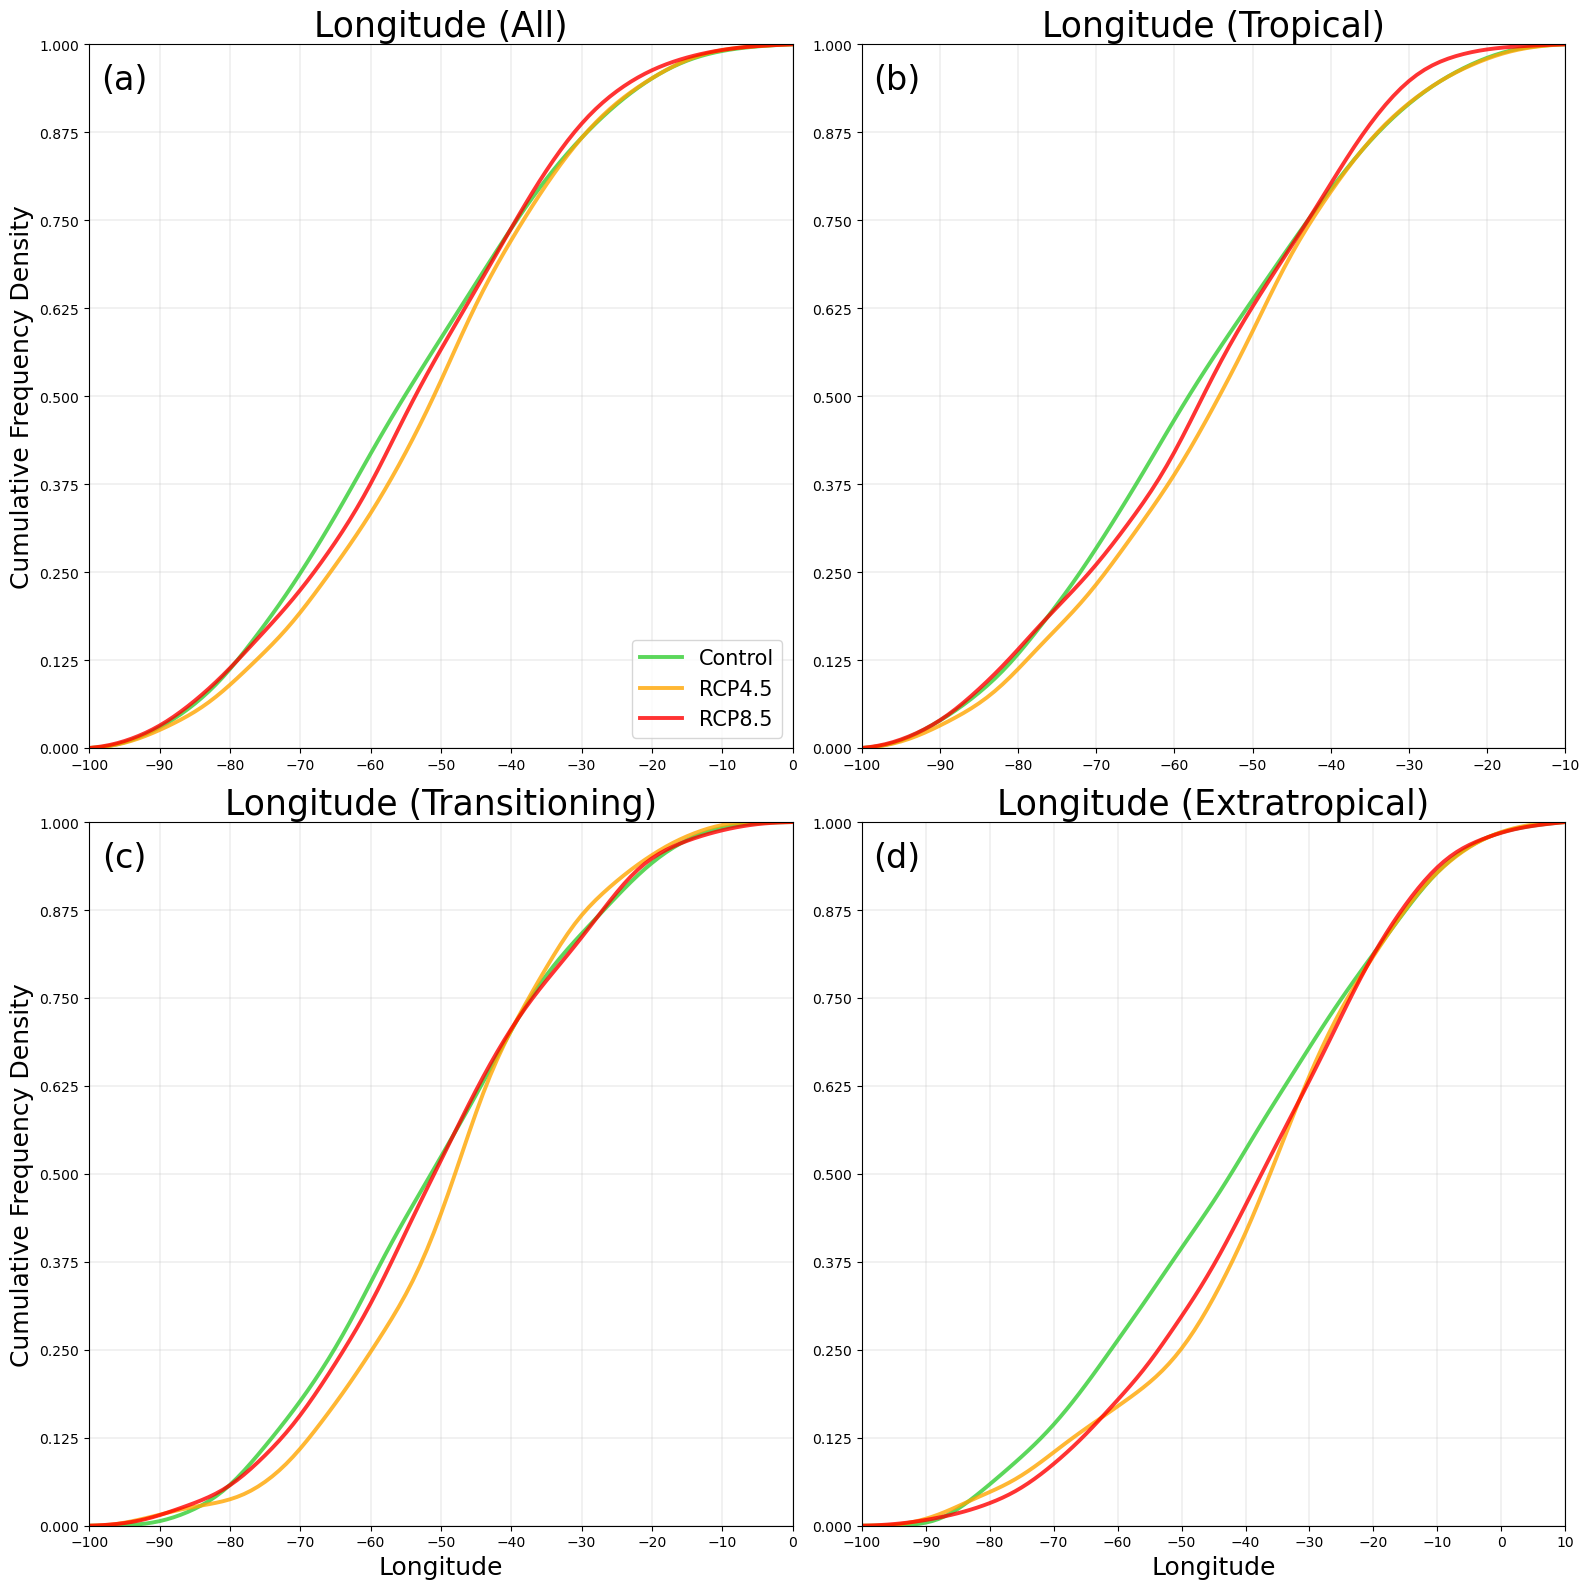

In [20]:
# Longitude at each 6-hourly datapoints for each storm phase
Var = "Lon"
Var_Label = "Longitude"
Horiz = False
Mins = [-100, -100, -100, -100]
Maxes = [0, -10, 0, 10]
Bin_Widths = [1, 1, 1, 1]
Label_Widths = [10, 10, 10, 10]
Smooth_Param = 0.15
Plot = "CDF"
Savefig = True
Figname = 'Lon_Phase_CDF.png'
Phase_Distr_Plot(Control_Data, RCP45_Data, RCP85_Data, Var, Var_Label, Horiz, \
Mins, Maxes, Bin_Widths, Label_Widths, Smooth_Param, Plot, Savefig, Figname)

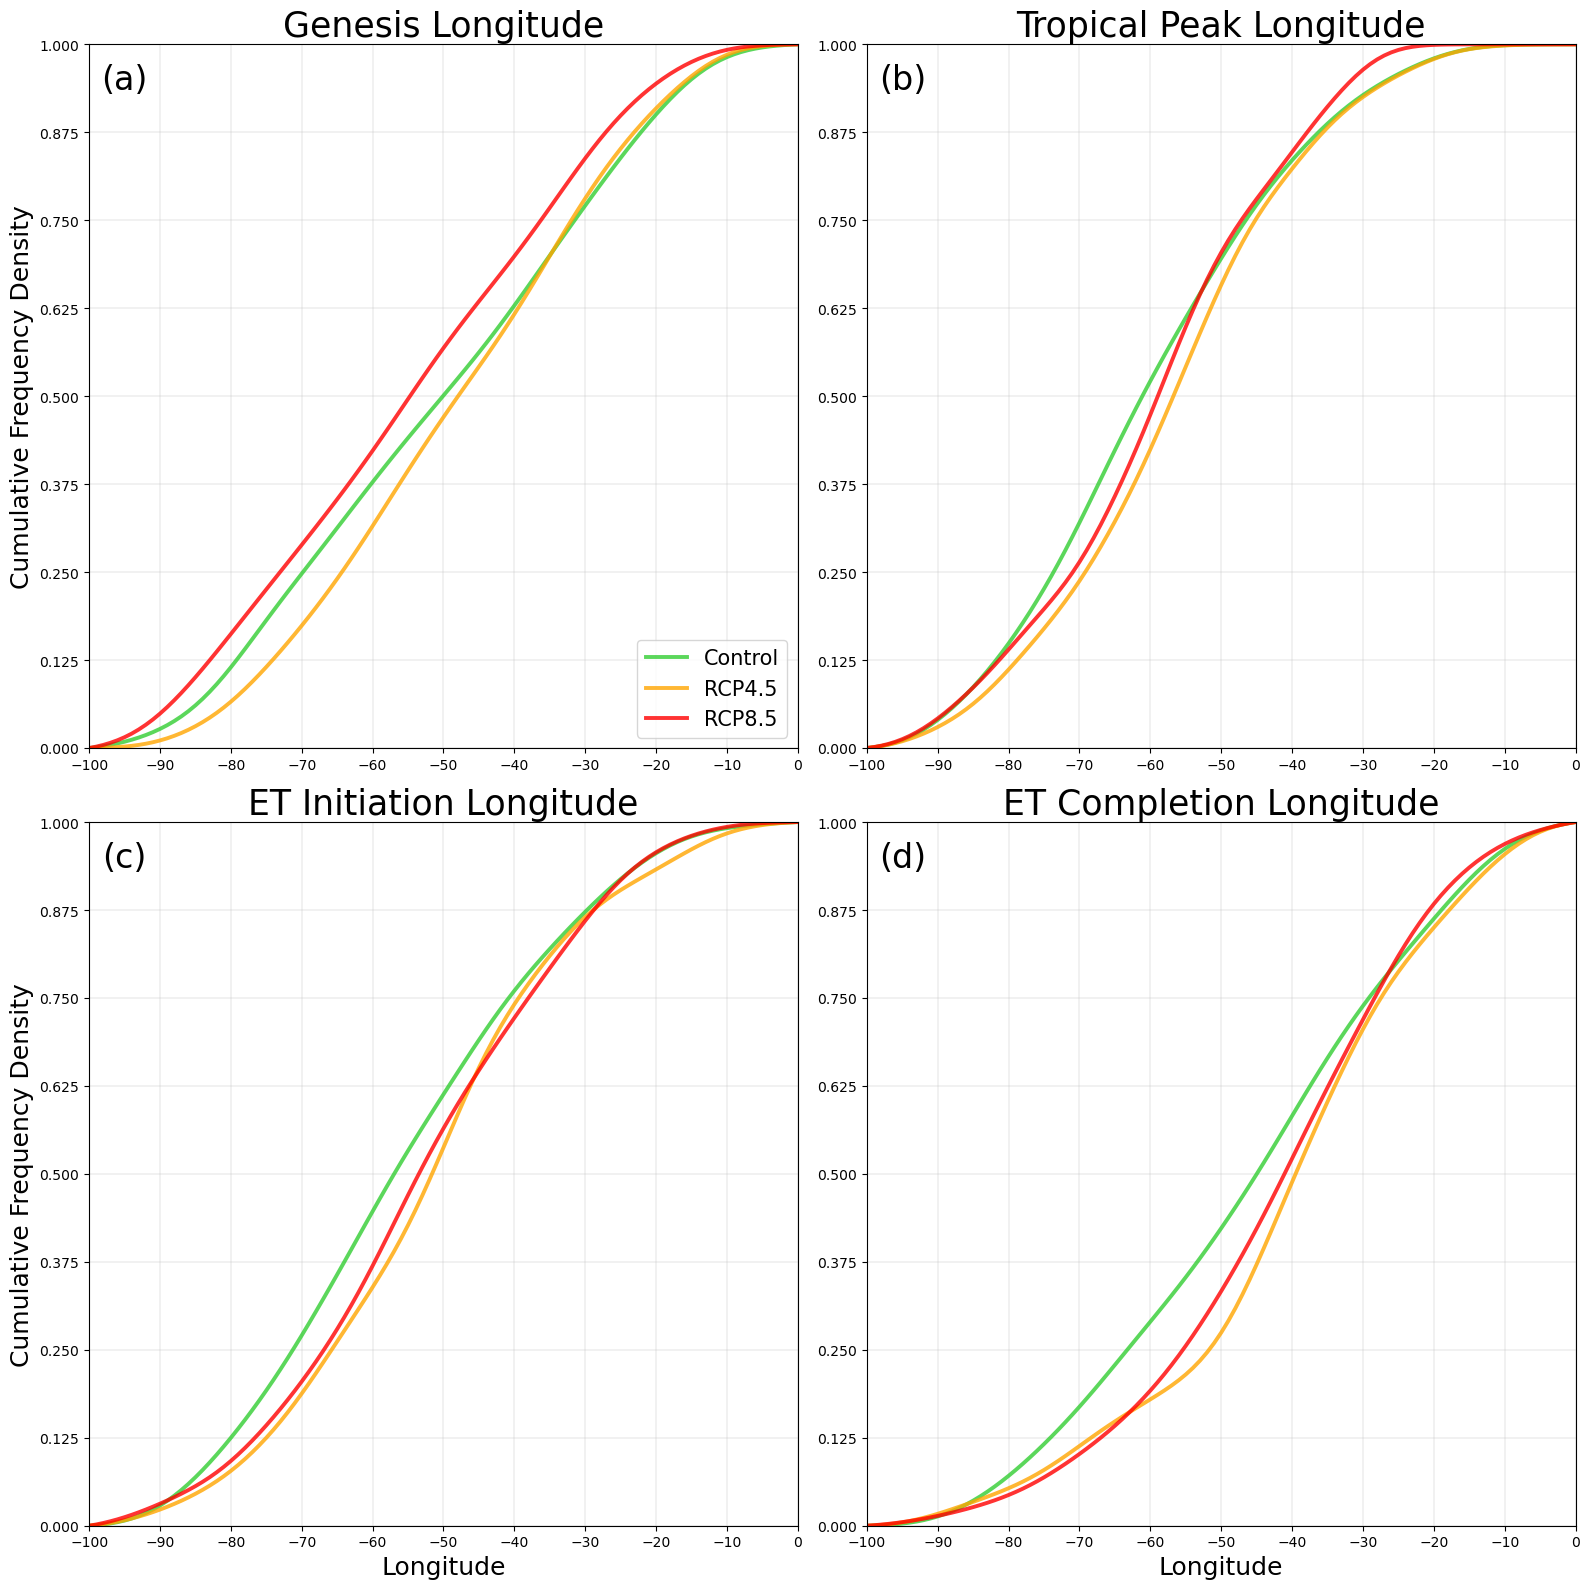

In [21]:
# Longitude at genesis, tropical peak, ET initiation and ET completion
Var = "Lon"
Var_Label = "Longitude"
Horiz = False
Mins = [-100, -100, -100, -100]
Maxes = [0, 0, 0, 0]
Bin_Widths = [1, 1, 1, 1]
Label_Widths = [10, 10, 10, 10]
Smooth_Param = 0.25
Plot = "CDF"
Savefig = True
Figname = 'Lon_ET_CDF.png'
ET_Distr_Plot(Control_ET, RCP45_ET, RCP85_ET, Var, Var_Label, Horiz, \
Mins, Maxes, Bin_Widths, Label_Widths, Smooth_Param, Plot, Savefig, Figname)

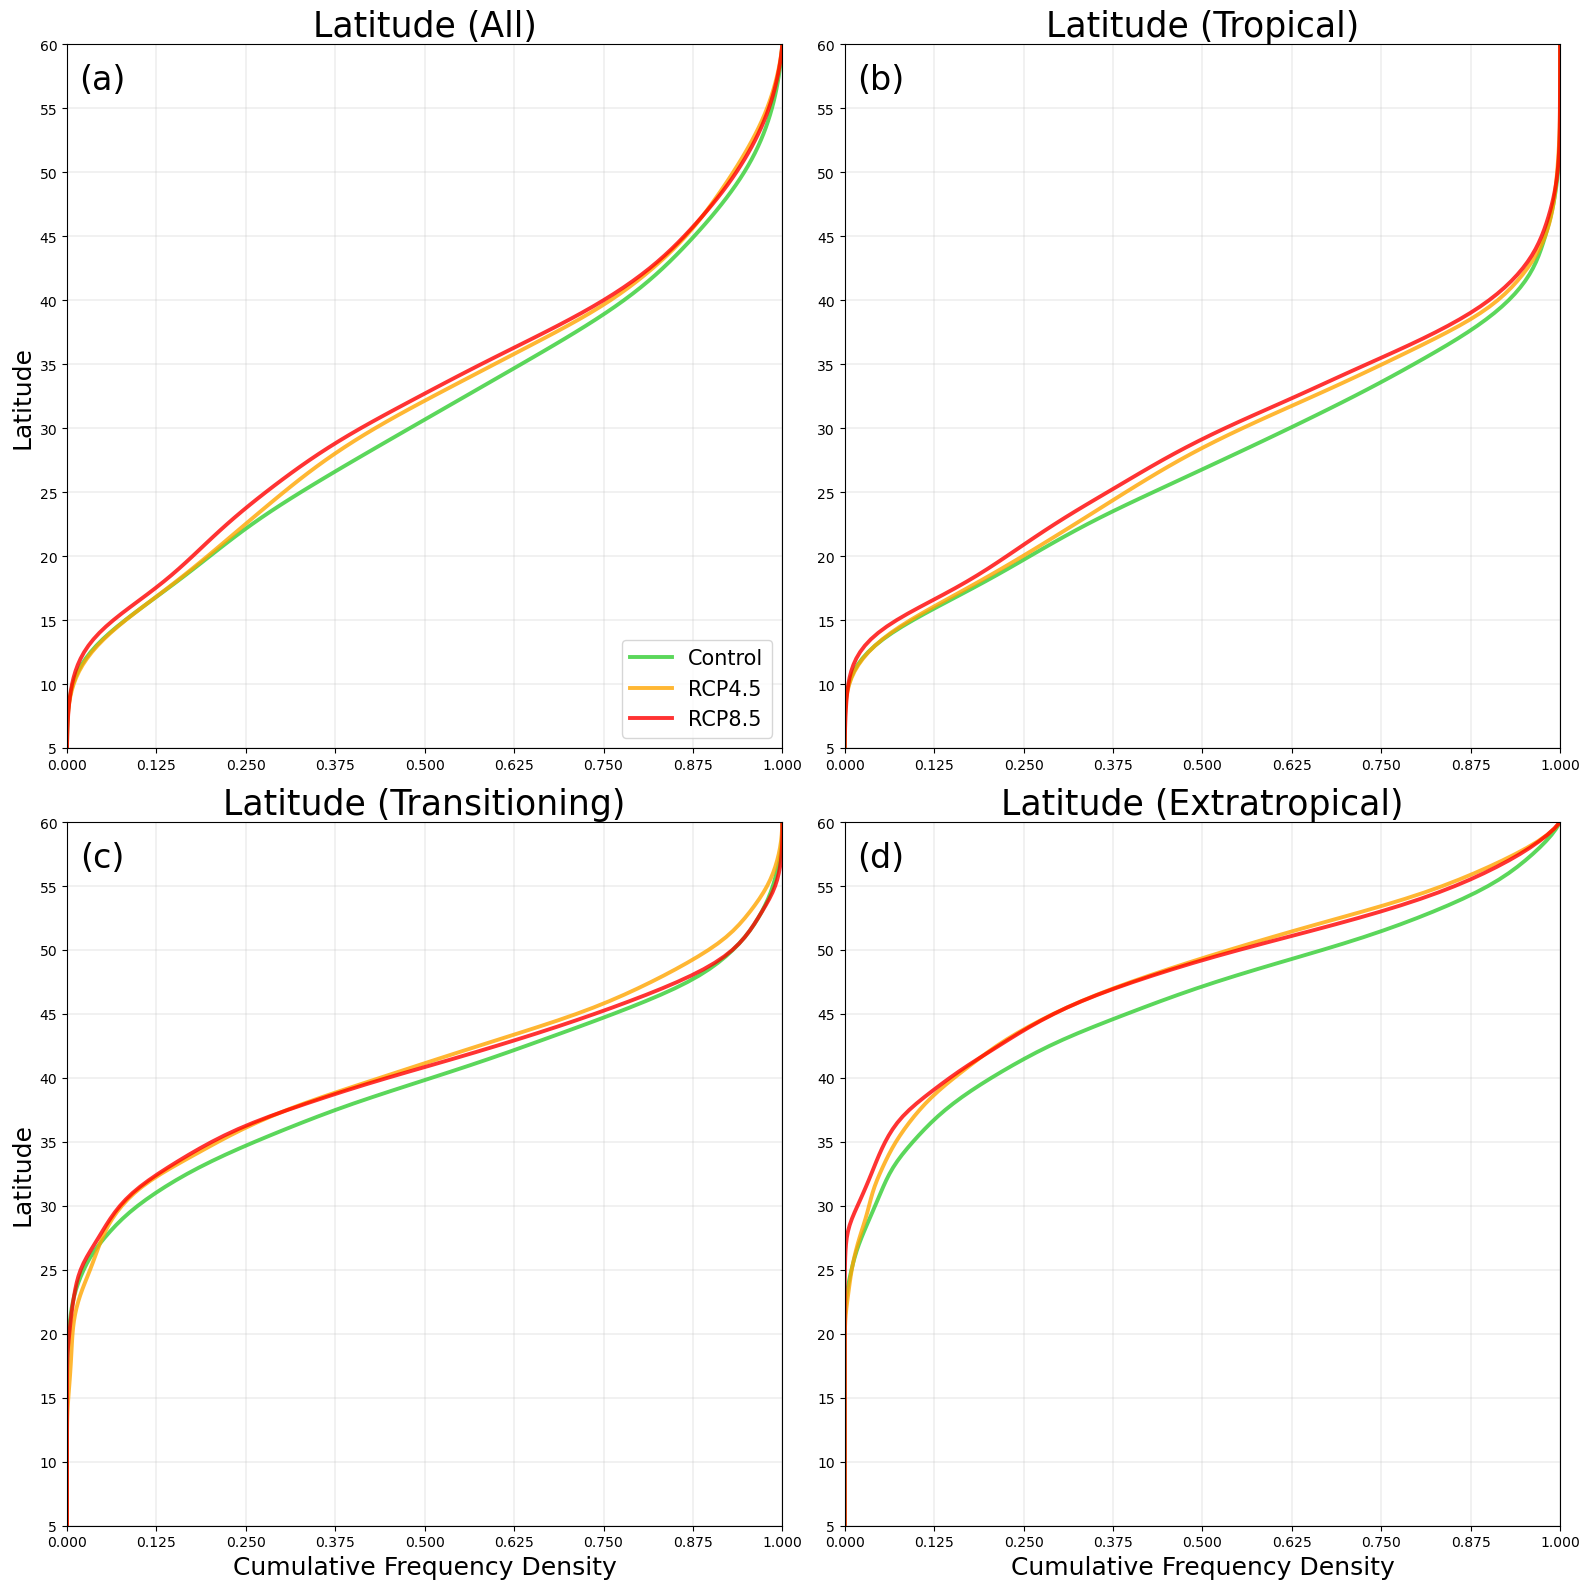

In [22]:
# Latitude at each 6-hourly datapoints for each storm phase
Var = "Lat"
Var_Label = "Latitude"
Horiz = True
Mins = [5, 5, 5, 5]
Maxes = [60, 60, 60, 60]
Bin_Widths = [0.5, 0.5, 0.5, 0.5]
Label_Widths = [5, 5, 5, 5]
Smooth_Param = 0.15
Plot = "CDF"
Savefig = True
Figname = 'Lat_Phase_CDF.png'
Phase_Distr_Plot(Control_Data, RCP45_Data, RCP85_Data, Var, Var_Label, Horiz, \
Mins, Maxes, Bin_Widths, Label_Widths, Smooth_Param, Plot, Savefig, Figname)

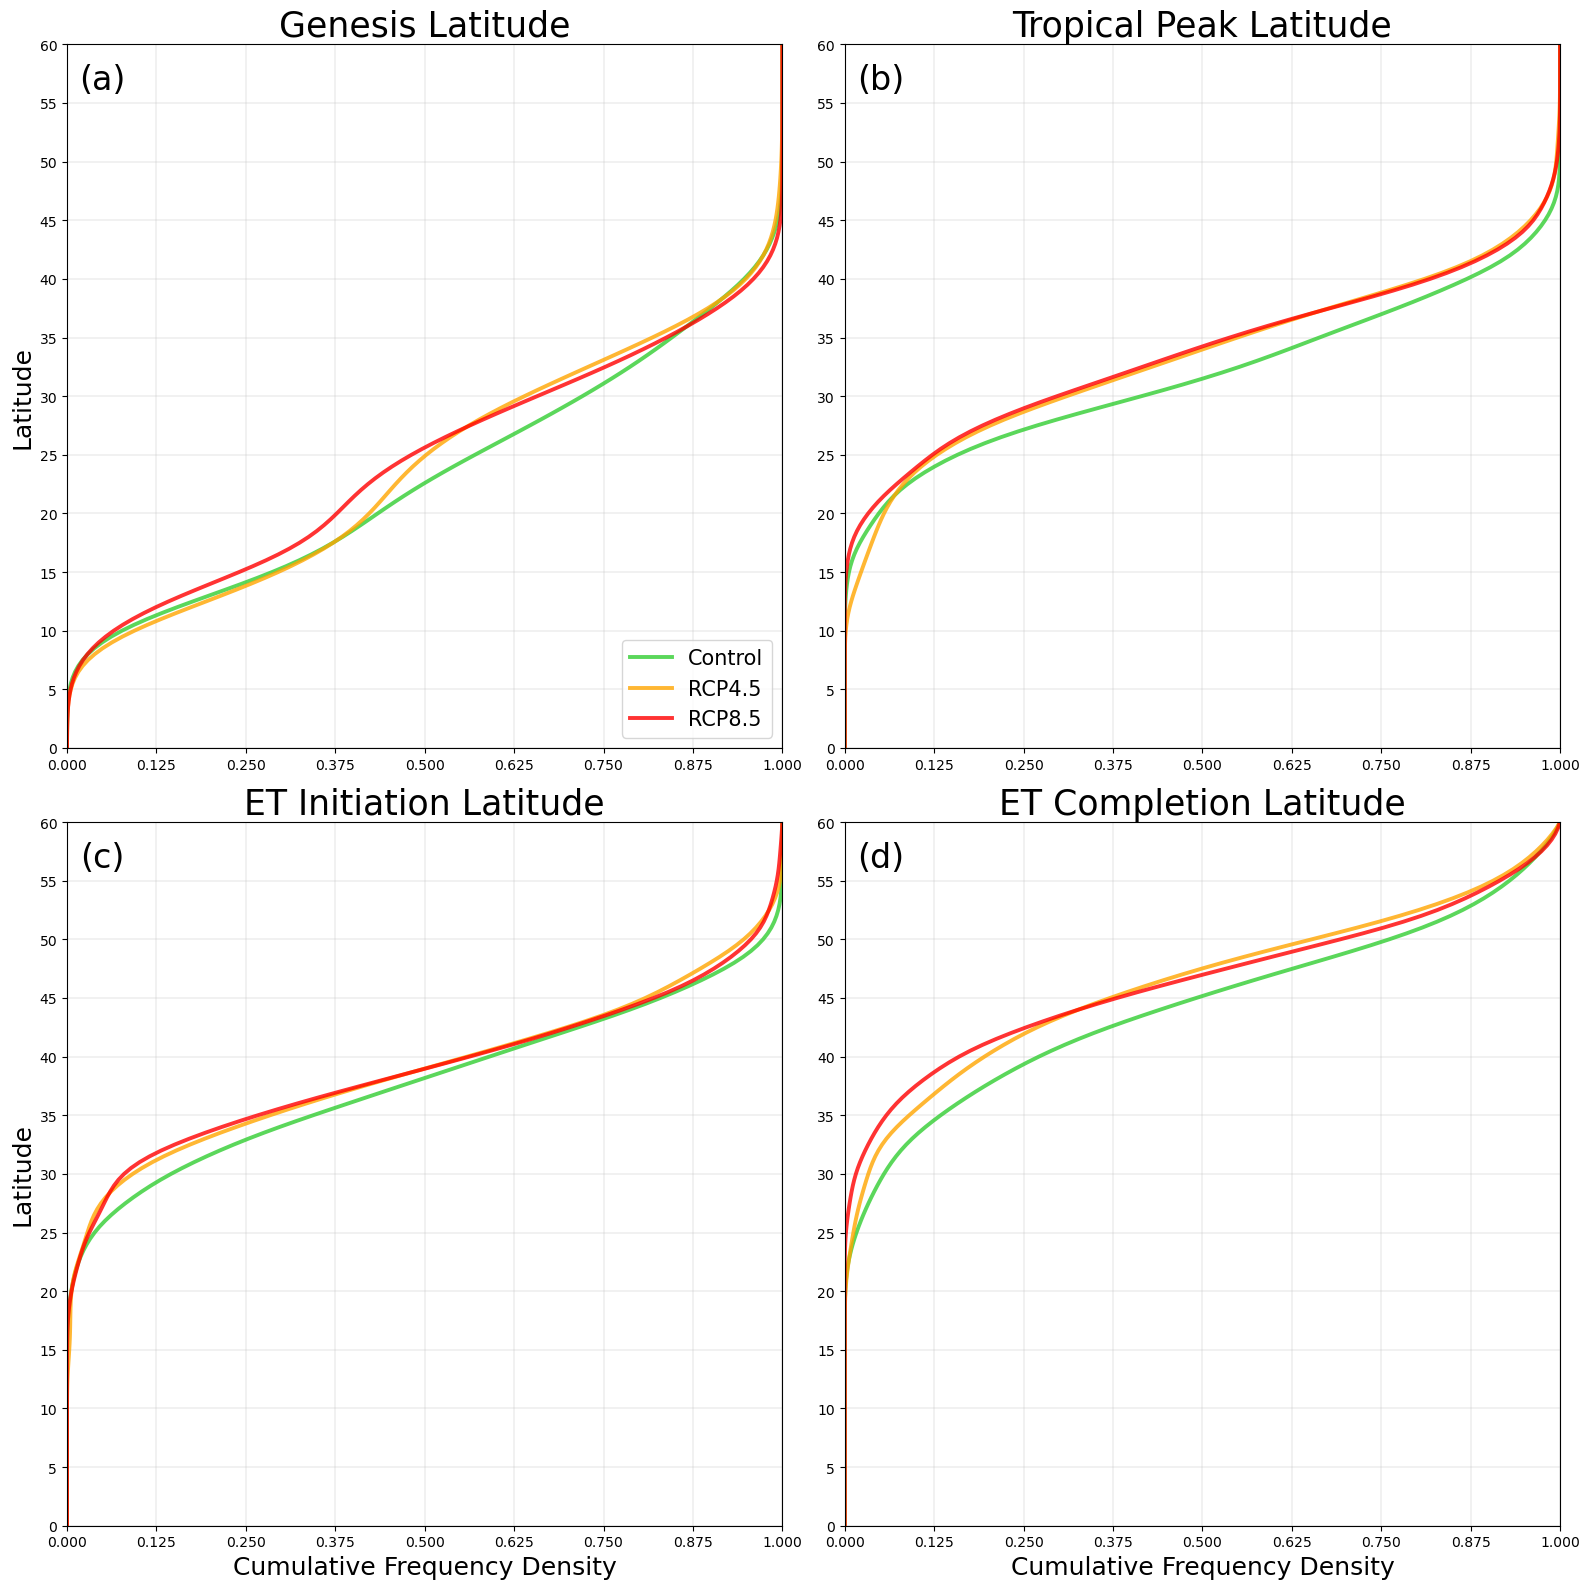

In [23]:
# Latitude at genesis, tropical peak, ET initiation and ET completion
Var = "Lat"
Var_Label = "Latitude"
Horiz = True
Mins = [0, 0, 0, 0]
Maxes = [60, 60, 60, 60]
Bin_Widths = [0.5, 0.5, 0.5, 0.5]
Label_Widths = [5, 5, 5, 5]
Smooth_Param = 0.25
Plot = "CDF"
Savefig = True
Figname = 'Lat_ET_CDF.png'
ET_Distr_Plot(Control_ET, RCP45_ET, RCP85_ET, Var, Var_Label, Horiz, \
Mins, Maxes, Bin_Widths, Label_Widths, Smooth_Param, Plot, Savefig, Figname)